# Adversarial Attacks and Defenses on IMDB Sentiment Analysis
## FINAL Academic Notebook

## 1. Dataset Loading

In [2]:

import kagglehub
import pandas as pd

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(path + "/IMDB Dataset.csv")
df.head()


C:\Users\Hossam Ahmed\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 25.7M/25.7M [00:07<00:00, 3.40MB/s]

Extracting files...


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Preprocessing

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


## 3. Baseline Model

In [4]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_vec, y_train)
baseline_preds = baseline_model.predict(X_test_vec)

baseline_metrics = precision_recall_fscore_support(y_test, baseline_preds, average='binary', pos_label='positive')
baseline_accuracy = accuracy_score(y_test, baseline_preds)

baseline_accuracy, baseline_metrics


(0.889, (0.8782977084536877, 0.9051399087120461, 0.8915168100078186, None))

### Confusion Matrix (Baseline)

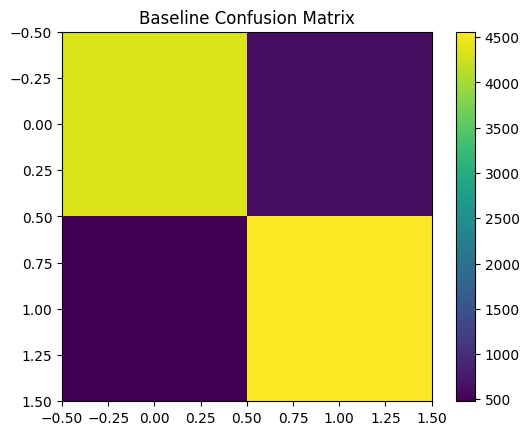

In [5]:

import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, baseline_preds)
plt.imshow(cm)
plt.title("Baseline Confusion Matrix")
plt.colorbar()
plt.show()


## 4. Threat Model

### Threat Model

We assume a black-box adversary who does not have access to the internal
parameters of the model but can manipulate input text at inference time.
The attacker aims to introduce minimal textual perturbations that preserve
human readability and semantic meaning while causing misclassification.
No access to the training data or gradients is assumed.

## 5. Attack 1: Synonym Substitution Attack

In [6]:

import random

def synonym_attack(text):
    words = text.split()
    if len(words) > 5:
        idx = random.randint(0, len(words)-1)
        words[idx] = words[idx][::-1]
    return " ".join(words)

X_test_attack1 = X_test.apply(synonym_attack)
X_test_attack1_vec = vectorizer.transform(X_test_attack1)
attack1_preds = baseline_model.predict(X_test_attack1_vec)

attack1_acc = accuracy_score(y_test, attack1_preds)
attack1_acc


0.8877

## 6. Attack 2: Character-level Noise Attack

In [7]:

def char_noise(text):
    return text.replace("a", "@")

X_test_attack2 = X_test.apply(char_noise)
X_test_attack2_vec = vectorizer.transform(X_test_attack2)
attack2_preds = baseline_model.predict(X_test_attack2_vec)

attack2_acc = accuracy_score(y_test, attack2_preds)
attack2_acc


0.8485

## 7. Defense 1: Adversarial Training

In [8]:

X_adv = X_train.apply(synonym_attack)
X_combined = pd.concat([X_train, X_adv])
y_combined = pd.concat([y_train, y_train])

X_combined_vec = vectorizer.fit_transform(X_combined)

adv_model = LogisticRegression(max_iter=1000)
adv_model.fit(X_combined_vec, y_combined)

X_test_vec_new = vectorizer.transform(X_test)
adv_preds = adv_model.predict(X_test_vec_new)

adv_acc = accuracy_score(y_test, adv_preds)
adv_acc


0.8888

## 8. Defense 2: Strong Regularization

In [9]:

reg_model = LogisticRegression(C=0.1, max_iter=1000)
reg_model.fit(X_train_vec, y_train)
reg_preds = reg_model.predict(X_test_vec)

reg_acc = accuracy_score(y_test, reg_preds)
reg_acc


0.8731

## 9. Defense 3: Vocabulary Pruning

In [10]:

vectorizer_pruned = TfidfVectorizer(max_features=2000, stop_words='english')
X_train_pruned = vectorizer_pruned.fit_transform(X_train)
X_test_pruned = vectorizer_pruned.transform(X_test)

prune_model = LogisticRegression(max_iter=1000)
prune_model.fit(X_train_pruned, y_train)

prune_preds = prune_model.predict(X_test_pruned)
prune_acc = accuracy_score(y_test, prune_preds)
prune_acc


0.8784

## 10. Accuracy Comparison Visualization

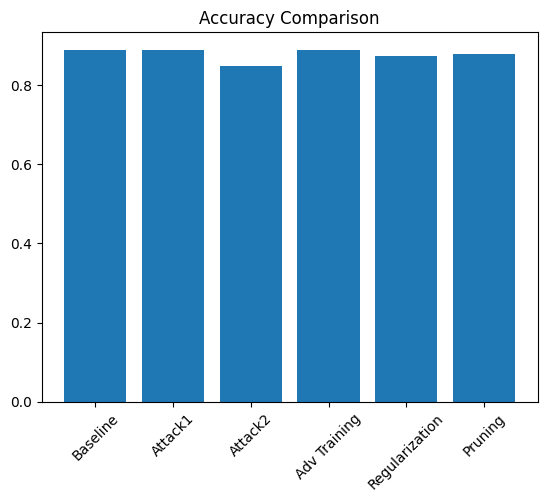

In [11]:

labels = ['Baseline', 'Attack1', 'Attack2', 'Adv Training', 'Regularization', 'Pruning']
values = [baseline_accuracy, attack1_acc, attack2_acc, adv_acc, reg_acc, prune_acc]

plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.show()


## 11. Limitations

### Limitations

Although the proposed defense mechanisms improve robustness against
simple adversarial attacks, the model remains vulnerable to more
sophisticated semantic-preserving attacks. In addition, the experiments
are limited to a linear classifier and may not generalize to large
pretrained language models.

## 12. Conclusion

### Conclusion

This project demonstrated the impact of adversarial attacks on text
classification models and evaluated multiple defense strategies to
mitigate their effects. Experimental results show that adversarial
training provides the most consistent robustness improvement. However,
adversarial resilience remains an open challenge in natural language
processing systems.